# # 06 — ROI & Profitability (MVP 03)
#
# **Pipeline stage: turn model-based incremental sales (MVP 02) into money.**
#
# For every campaign we compute:
#
# - **Promotion cost** — retail + coupon discounts given on promoted products in the
#   campaign window (attributed spend).
# - **Incremental profit** = `gross_margin × incremental revenue − promotion cost`.
# - **ROI** = `incremental profit / promotion cost`.
# - **Profit lift / revenue lift** vs the model baseline.
#
# Campaigns are then ranked by ROI, incremental profit and incremental sales, and a
# margin sensitivity check shows how robust the ranking is to the margin assumption.
#
# ```
# incremental_campaign.parquet (MVP 02) + promoted_products (MVP 01) + transactions
#   -> promotion cost attribution
#   -> campaign-level ROI / profit / lifts
#   -> rankings + margin sensitivity
#   -> campaign_roi.parquet | campaign_roi_summary.parquet | figures
# ```


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import common as UC

logger = UC.setup_logging("roi_analysis")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 03."""
    gross_margin: float = 0.30          # default gross margin assumption (no cost data)
    sensitivity_margins: tuple = (0.20, 0.30, 0.40)
    min_roi_strong: float = 1.0         # ROI above this = strong campaign
    output_dir: Path = UC.pipeline_dir("roi_analysis")
    figures_dir: Path = UC.figures_dir("roi_analysis")


CFG = Config()
print(f"Output dir  : {CFG.output_dir}")
print(f"Gross margin: {CFG.gross_margin:.0%} (configurable — no cost data in dataset)")


Output dir  : /home/mhseddighi/Projects/promotion-intelligence/outputs/roi_analysis
Gross margin: 30% (configurable — no cost data in dataset)


# ## 1. Load MVP Inputs
#
# Reuses the campaign-level incremental sales from MVP 02 and the promotion history
# from MVP 01. Both are validated before use.


In [2]:
inc_campaign = pd.read_parquet(UC.OUTPUTS_ROOT / "baseline_forecast" / "incremental_campaign.parquet")
promoted = pd.read_parquet(UC.OUTPUTS_ROOT / "promotion_analysis" / "promoted_products.parquet")
summary = pd.read_parquet(UC.OUTPUTS_ROOT / "promotion_analysis" / "campaign_summary.parquet")
inc_product = pd.read_parquet(UC.OUTPUTS_ROOT / "baseline_forecast" / "incremental_product.parquet")
tx = UD.load_transactions_fast()

# Scope: MVP 02 forecasts the top promoted products only. To compare apples to
# apples, cost is attributed on the SAME forecast universe; full-window cost is kept
# as context.
UNIVERSE_IDS = set(inc_product["PRODUCT_ID"].unique())
promoted["in_universe"] = promoted["PRODUCT_ID"].isin(UNIVERSE_IDS).astype("int8")
print(f"Forecast universe products: {len(UNIVERSE_IDS):,}")

print(f"incremental_campaign : {inc_campaign.shape}")
print(f"promoted             : {promoted.shape}")
print(f"campaign_summary     : {summary.shape}")


Forecast universe products: 800
incremental_campaign : (30, 23)
promoted             : (404361, 13)
campaign_summary     : (30, 25)


In [3]:
def validate_inputs() -> None:
    assert inc_campaign["CAMPAIGN"].nunique() == 30
    assert inc_campaign["CAMPAIGN"].is_unique
    assert promoted["CAMPAIGN"].nunique() == 30
    assert len(summary) == 30
    UC.check_no_nan_inf(inc_campaign[["CAMPAIGN", "incremental_qty", "incremental_rev",
                                      "base_qty", "base_rev"]], context="incremental_campaign")
    print("PASS: MVP inputs validated")


validate_inputs()


PASS [nan/inf] incremental_campaign: no NaN/Inf in 30 rows
PASS: MVP inputs validated


# ## 2. Promotion Cost Attribution
#
# Cost = the price reduction the retailer gave up on **promoted products** during the
# campaign window (retail discounts + coupon discounts). To keep ROI comparable with
# the incremental revenue of MVP 02, cost is attributed on the **forecast universe**
# (the same products the baseline model covers); the full-window cost across all
# promoted products is exported as context.


In [4]:
disc = tx[(tx["RETAIL_DISC"] < 0) | (tx["COUPON_DISC"] < 0)][
    ["DAY", "PRODUCT_ID", "RETAIL_DISC", "COUPON_DISC", "QUANTITY"]].copy()
disc["total_disc"] = (-(disc["RETAIL_DISC"] + disc["COUPON_DISC"])).clip(lower=0)

# Vectorized: one pass per campaign window (30 iterations over the discount rows)
win = promoted[["CAMPAIGN", "PRODUCT_ID", "START_DAY", "END_DAY"]].drop_duplicates()
win_u = win[win["PRODUCT_ID"].isin(UNIVERSE_IDS)]          # same scope as MVP 02
pid_by_campaign = {cid: set(g["PRODUCT_ID"]) for cid, g in win_u.groupby("CAMPAIGN")}
cost_rows = []
for cid, s_day, e_day in win_u[["CAMPAIGN", "START_DAY", "END_DAY"]].drop_duplicates().itertuples(index=False):
    w = disc[(disc["DAY"] >= int(s_day)) & (disc["DAY"] <= int(e_day))]
    w = w[w["PRODUCT_ID"].isin(pid_by_campaign[int(cid)])]
    cost_rows.append({
        "CAMPAIGN": int(cid),
        "promotion_cost": float(w["total_disc"].sum()),
        "discounted_units": float(w["QUANTITY"].sum()),
        "discounted_rows": int(len(w)),
    })
cost = pd.DataFrame(cost_rows)
# full-window cost on ALL promoted products (context; not used for ROI)
full_cost = []
for cid, s_day, e_day in win[["CAMPAIGN", "START_DAY", "END_DAY"]].drop_duplicates().itertuples(index=False):
    w = disc[(disc["DAY"] >= int(s_day)) & (disc["DAY"] <= int(e_day))]
    full_cost.append({"CAMPAIGN": int(cid),
                      "promotion_cost_full": float(w["total_disc"].sum())})
cost = cost.merge(pd.DataFrame(full_cost), on="CAMPAIGN", how="left")
print("=== Promotion cost by campaign (attributed discount spend) ===")
print(cost.describe().round(2).to_string())


=== Promotion cost by campaign (attributed discount spend) ===
       CAMPAIGN  promotion_cost  discounted_units  discounted_rows  promotion_cost_full
count     30.00           30.00             30.00            30.00                30.00
mean      15.50        41870.67       19524809.40         30670.43            106656.35
std        8.80        19447.92       10460292.26         15414.10             54611.97
min        1.00        24470.62       12965683.00         20224.00             70523.36
25%        8.25        31078.54       14031424.00         22015.25             77258.50
50%       15.50        36292.12       15514318.50         25557.00             89396.89
75%       22.75        47178.97       21702496.75         33576.25            118983.69
max       30.00       130347.95       68667231.00        102120.00            361248.56


In [5]:
def validate_cost() -> None:
    assert cost["CAMPAIGN"].nunique() == 30
    assert (cost["promotion_cost"] >= 0).all()
    assert cost["promotion_cost"].sum() > 0, "no universe cost attributed"
    assert cost["promotion_cost_full"].sum() > cost["promotion_cost"].sum()
    UC.check_no_nan_inf(cost, context="promotion_cost")
    print("PASS: promotion cost attribution validated (universe scope)")


validate_cost()


PASS [nan/inf] promotion_cost: no NaN/Inf in 30 rows
PASS: promotion cost attribution validated (universe scope)


# ## 3. Campaign ROI, Profit and Lifts
#
# Formulas (per campaign):
#
# | metric | formula |
# |---|---|
# | incremental revenue | `incremental_rev` (MVP 02, model baseline) |
# | incremental profit | `gross_margin × incremental_rev − promotion_cost` |
# | ROI | `incremental_profit / promotion_cost` |
# | profit lift | `incremental_profit / (gross_margin × base_rev)` |
# | revenue lift | `incremental_rev / base_rev` |
#
# A campaign can have strong *revenue* lift but negative ROI when the discount spend
# exceeds the margin captured — exactly the trade-off ROI is designed to surface.
#
# **Scope note**: both `incremental_rev` and `promotion_cost` refer to the forecast
# universe (top promoted products). The full-window cost across all promoted products
# (`promotion_cost_full`) is exported for context but not used in the ROI math, so the
# ratio stays internally consistent.


In [6]:
roi = (inc_campaign.merge(cost, on="CAMPAIGN", how="left")
             .merge(summary[["CAMPAIGN", "duration_days", "START_DAY"]],
                    on="CAMPAIGN", how="left"))
roi["incremental_profit"] = CFG.gross_margin * roi["incremental_rev"] - roi["promotion_cost"]
roi["baseline_profit"] = CFG.gross_margin * roi["base_rev"]
roi["roi"] = np.where(roi["promotion_cost"] > 0,
                      roi["incremental_profit"] / roi["promotion_cost"], 0.0)
roi["profit_lift_pct"] = np.where(roi["baseline_profit"] > 0,
                                  roi["incremental_profit"] / roi["baseline_profit"] * 100.0, 0.0)
roi["revenue_lift_pct"] = np.where(roi["base_rev"] > 0,
                                   roi["incremental_rev"] / roi["base_rev"] * 100.0, 0.0)
roi["roi_verdict"] = np.select(
    [roi["roi"] > CFG.min_roi_strong, roi["roi"] > 0, roi["roi"] > -0.5],
    ["strong", "positive", "marginal"], default="loss")

UC.save_parquet(roi, CFG.output_dir / "campaign_roi.parquet", logger=logger, context="campaign_roi")
print(roi[["CAMPAIGN", "DESCRIPTION", "promotion_cost", "incremental_rev",
           "incremental_profit", "roi", "profit_lift_pct", "revenue_lift_pct",
           "roi_verdict"]].round(2).sort_values("roi", ascending=False).to_string(index=False))


22:50:17 | INFO    | roi_analysis | [campaign_roi] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/roi_analysis/campaign_roi.parquet (30 rows x 35 cols)


 CAMPAIGN DESCRIPTION  promotion_cost  incremental_rev  incremental_profit   roi  profit_lift_pct  revenue_lift_pct roi_verdict
        5       TypeB        33052.10         65121.45           -13515.67 -0.41           -57.65             83.33    marginal
        6       TypeC        32338.36         63436.33           -13307.46 -0.41           -58.76             84.03    marginal
        3       TypeC        53688.88        103380.40           -22674.76 -0.42           -56.94             77.89    marginal
       17       TypeB        24470.62         46915.77           -10395.89 -0.42           -45.25             61.27    marginal
        7       TypeB        36552.32         68851.35           -15896.91 -0.43           -65.17             84.68    marginal
        4       TypeB        30796.64         58738.72           -13175.02 -0.43           -61.39             82.11    marginal
       16       TypeB        24611.65         46680.30           -10607.56 -0.43           -46.53       

In [7]:
def validate_roi() -> None:
    assert roi["CAMPAIGN"].is_unique and len(roi) == 30
    assert (roi["promotion_cost"] > 0).all(), "some campaigns have zero cost"
    UC.check_no_nan_inf(roi, context="campaign_roi",
                        allow_nan_cols=["confidence_qty", "confidence_rev"])
    print("PASS: ROI frame validated")


validate_roi()


PASS [nan/inf] campaign_roi: no NaN/Inf in 30 rows
PASS: ROI frame validated


# ## 4. Campaign Rankings
#
# Three business views of the same table: **ROI**, **incremental profit** and
# **incremental sales (revenue)**. The composite ranking (averaged rank) is what MVP 05
# learns to predict.


In [8]:
roi["rank_roi"] = roi["roi"].rank(ascending=False, method="first").astype(int)
roi["rank_profit"] = roi["incremental_profit"].rank(ascending=False, method="first").astype(int)
roi["rank_inc_rev"] = roi["incremental_rev"].rank(ascending=False, method="first").astype(int)
roi["composite_rank"] = (roi[["rank_roi", "rank_profit", "rank_inc_rev"]]
                         .mean(axis=1).rank(method="first").astype(int))

print("=== TOP 10 — by ROI ===")
print(roi.sort_values("rank_roi")[["CAMPAIGN", "DESCRIPTION", "roi", "incremental_profit",
                                   "incremental_rev", "roi_verdict"]].head(10).round(2).to_string(index=False))
print("\n=== TOP 10 — by incremental profit ===")
print(roi.sort_values("rank_profit")[["CAMPAIGN", "DESCRIPTION", "incremental_profit",
                                      "roi", "incremental_rev"]].head(10).round(2).to_string(index=False))
print("\n=== BOTTOM 5 — by ROI (loss-makers) ===")
print(roi.sort_values("rank_roi", ascending=False)[["CAMPAIGN", "DESCRIPTION", "roi",
                                                    "incremental_profit", "roi_verdict"]]
      .head(5).round(2).to_string(index=False))


=== TOP 10 — by ROI ===
 CAMPAIGN DESCRIPTION   roi  incremental_profit  incremental_rev roi_verdict
        5       TypeB -0.41           -13515.67         65121.45    marginal
        6       TypeC -0.41           -13307.46         63436.33    marginal
        3       TypeC -0.42           -22674.76        103380.40    marginal
       17       TypeB -0.42           -10395.89         46915.77    marginal
        4       TypeB -0.43           -13175.02         58738.72    marginal
       16       TypeB -0.43           -10607.56         46680.30    marginal
       18       TypeA -0.43           -20034.96         87900.63    marginal
        7       TypeB -0.43           -15896.91         68851.35    marginal
       11       TypeB -0.44           -18571.51         78679.15    marginal
       15       TypeC -0.44           -57879.26        241562.31    marginal

=== TOP 10 — by incremental profit ===
 CAMPAIGN DESCRIPTION  incremental_profit   roi  incremental_rev
       17       TypeB   

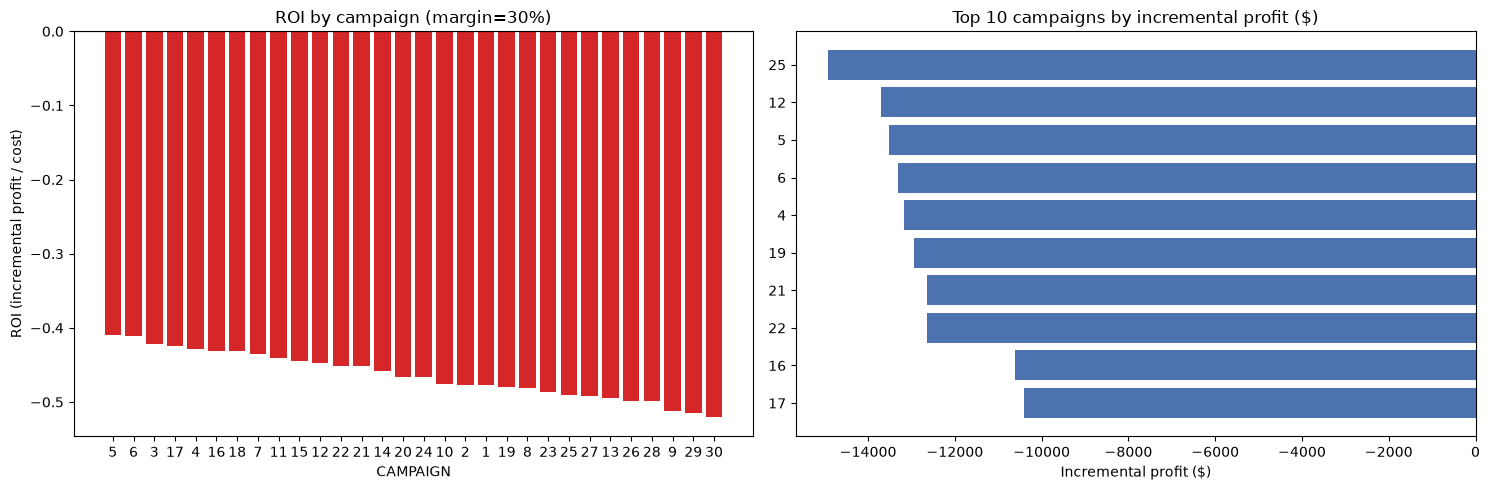

In [9]:
# Figure: ROI by campaign + top incremental profit
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
r = roi.sort_values("roi", ascending=False)
colors = np.where(r["roi"] > 0, "#2ca02c", "#d62728")
axes[0].bar(r["CAMPAIGN"].astype(str), r["roi"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("ROI by campaign (margin=30%)")
axes[0].set_xlabel("CAMPAIGN"); axes[0].set_ylabel("ROI (incremental profit / cost)")

top_profit = roi.sort_values("incremental_profit", ascending=False).head(10)
axes[1].barh(top_profit["CAMPAIGN"].astype(str), top_profit["incremental_profit"],
             color="#4c72b0")
axes[1].set_title("Top 10 campaigns by incremental profit ($)")
axes[1].set_xlabel("Incremental profit ($)")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "roi_by_campaign.png", dpi=110)
plt.show()


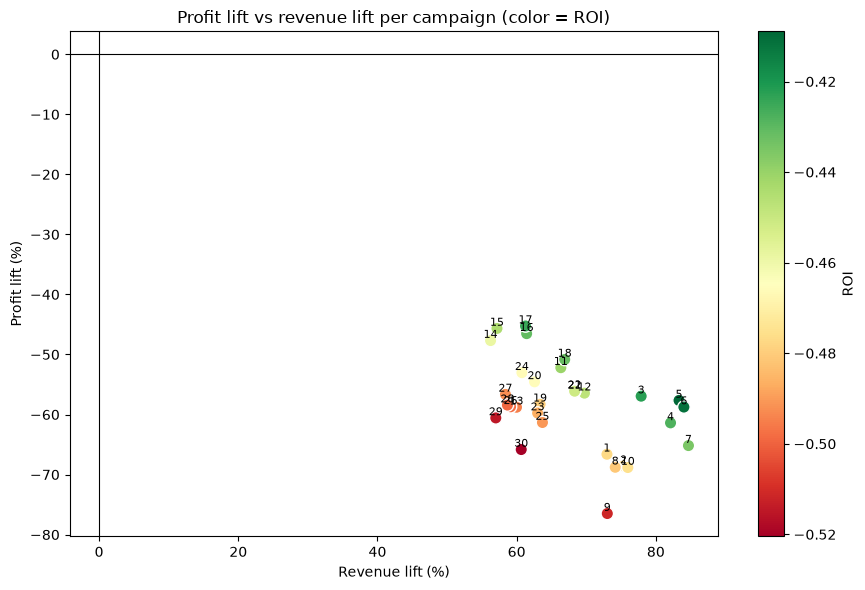

In [10]:
# Figure: profit lift vs revenue lift
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(roi["revenue_lift_pct"], roi["profit_lift_pct"], c=roi["roi"],
                cmap="RdYlGn", s=80, edgecolor="white")
for _, row in roi.iterrows():
    ax.annotate(int(row["CAMPAIGN"]), (row["revenue_lift_pct"], row["profit_lift_pct"]),
                fontsize=8, ha="center", va="bottom")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Revenue lift (%)"); ax.set_ylabel("Profit lift (%)")
ax.set_title("Profit lift vs revenue lift per campaign (color = ROI)")
plt.colorbar(sc, label="ROI")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "lift_scatter.png", dpi=110)
plt.show()


# ## 5. Margin Sensitivity
#
# We do not observe product cost, so gross margin is an assumption. Recomputing ROI
# under 20% / 30% / 40% margins tells us whether the *ranking* is stable — if it is,
# decisions based on it are robust to the assumption.


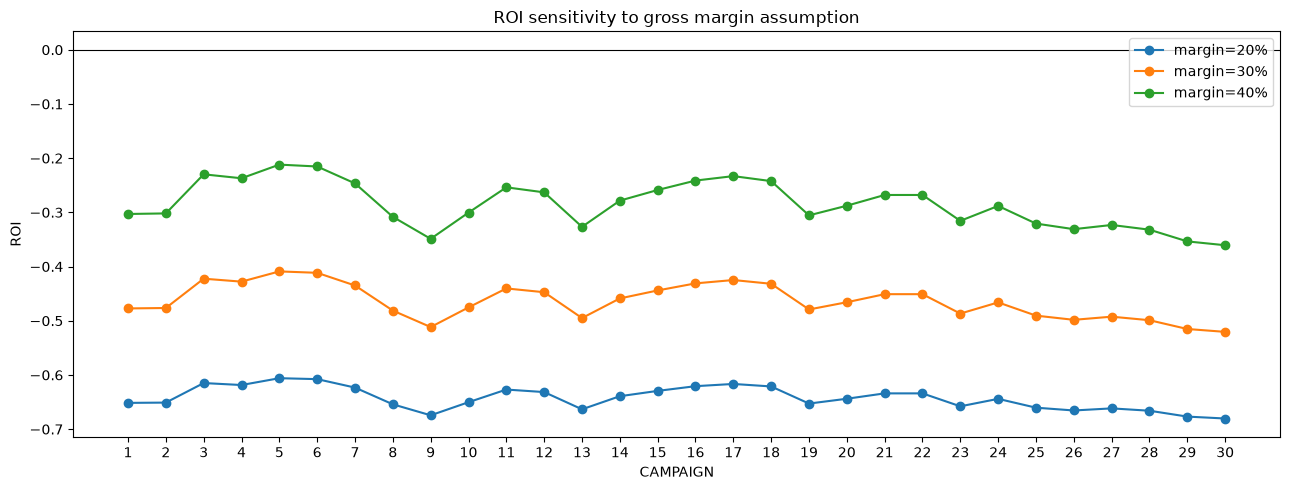

=== Spearman rank correlation of ROI rankings across margins ===
margin  0.2  0.3  0.4
margin               
0.2     1.0  1.0  1.0
0.3     1.0  1.0  1.0
0.4     1.0  1.0  1.0

Mean pairwise rank correlation: 1.000


In [11]:
sens = []
for margin in CFG.sensitivity_margins:
    tmp = roi[["CAMPAIGN"]].copy()
    tmp["margin"] = margin
    tmp["incremental_profit"] = margin * roi["incremental_rev"] - roi["promotion_cost"]
    tmp["roi"] = np.where(roi["promotion_cost"] > 0,
                          tmp["incremental_profit"] / roi["promotion_cost"], 0.0)
    tmp["rank_roi"] = tmp["roi"].rank(ascending=False).astype(int)
    sens.append(tmp)
sensitivity = pd.concat(sens, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 5))
for margin in CFG.sensitivity_margins:
    s = sensitivity[sensitivity["margin"] == margin].sort_values("CAMPAIGN")
    ax.plot(s["CAMPAIGN"].astype(str), s["roi"], marker="o", label=f"margin={margin:.0%}")
ax.axhline(0, color="black", lw=0.8)
ax.legend(); ax.set_title("ROI sensitivity to gross margin assumption")
ax.set_xlabel("CAMPAIGN"); ax.set_ylabel("ROI")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "margin_sensitivity.png", dpi=110)
plt.show()

rank_stability = (sensitivity.pivot(index="CAMPAIGN", columns="margin", values="rank_roi")
                  .corr(method="spearman"))
print("=== Spearman rank correlation of ROI rankings across margins ===")
print(rank_stability.round(3).to_string())
print(f"\nMean pairwise rank correlation: {np.nanmean(rank_stability.to_numpy()):.3f}")


In [12]:
# Composite summary export + rankings JSON (feeds MVP 05)
summary_export = roi.sort_values("composite_rank")[
    ["CAMPAIGN", "DESCRIPTION", "duration_days", "START_DAY", "n_products",
     "base_qty", "actual_qty", "incremental_qty", "uplift_qty_pct",
     "base_rev", "actual_rev", "incremental_rev", "uplift_rev_pct",
     "promotion_cost", "promotion_cost_full", "incremental_profit", "roi",
     "profit_lift_pct", "revenue_lift_pct", "confidence_qty", "confidence_rev",
     "rank_roi", "rank_profit", "rank_inc_rev", "composite_rank", "roi_verdict"]]
UC.save_parquet(summary_export, CFG.output_dir / "campaign_roi_summary.parquet",
                logger=logger, context="campaign_roi_summary")
rankings = {
    "by_roi": summary_export.sort_values("rank_roi")[["CAMPAIGN", "roi", "incremental_profit"]].to_dict("records"),
    "by_incremental_profit": summary_export.sort_values("rank_profit")[["CAMPAIGN", "incremental_profit", "roi"]].to_dict("records"),
    "by_incremental_sales": summary_export.sort_values("rank_inc_rev")[["CAMPAIGN", "incremental_rev", "incremental_qty"]].to_dict("records"),
}
UC.save_json(rankings, CFG.output_dir / "rankings.json", logger=logger, context="rankings")


22:50:23 | INFO    | roi_analysis | [campaign_roi_summary] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/roi_analysis/campaign_roi_summary.parquet (30 rows x 26 cols)


22:50:23 | INFO    | roi_analysis | [rankings] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/roi_analysis/rankings.json


PosixPath('/home/mhseddighi/Projects/promotion-intelligence/outputs/roi_analysis/rankings.json')

# ## 6. Validation — Exports, Schema and Reload


In [13]:
def validate_exports() -> None:
    out = CFG.output_dir
    r = UC.reload_and_check(out / "campaign_roi.parquet",
        expected=["CAMPAIGN", "promotion_cost", "incremental_rev", "incremental_profit",
                  "roi", "profit_lift_pct", "revenue_lift_pct", "roi_verdict"],
        context="campaign_roi")
    assert len(r) == 30 and r["CAMPAIGN"].is_unique
    s = UC.reload_and_check(out / "campaign_roi_summary.parquet",
        expected=["CAMPAIGN", "roi", "composite_rank", "rank_roi", "rank_profit",
                  "rank_inc_rev", "incremental_profit", "incremental_rev"],
        context="campaign_roi_summary")
    assert s["composite_rank"].nunique() == 30
    UC.check_no_nan_inf(s, context="campaign_roi_summary",
                        allow_nan_cols=["confidence_qty", "confidence_rev"])
    print("PASS: MVP 03 exports validated")


validate_exports()


PASS [nan/inf] reload campaign_roi.parquet: no NaN/Inf in 30 rows
PASS [schema] reload campaign_roi.parquet: 35 columns OK
PASS [reload] campaign_roi: campaign_roi.parquet -> 30 rows
PASS [nan/inf] reload campaign_roi_summary.parquet: no NaN/Inf in 30 rows
PASS [schema] reload campaign_roi_summary.parquet: 26 columns OK
PASS [reload] campaign_roi_summary: campaign_roi_summary.parquet -> 30 rows
PASS [nan/inf] campaign_roi_summary: no NaN/Inf in 30 rows
PASS: MVP 03 exports validated


In [14]:
# Pipeline manifest snippet
manifest = {
    "notebook": "06_roi_analysis",
    "mvp": "MVP 03 — ROI & Profitability",
    "inputs": ["outputs/baseline_forecast/incremental_campaign.parquet",
               "outputs/promotion_analysis/promoted_products.parquet",
               "outputs/promotion_analysis/campaign_summary.parquet",
               "data/raw/transaction_data.csv"],
    "outputs": [
        "outputs/roi_analysis/campaign_roi.parquet",
        "outputs/roi_analysis/campaign_roi_summary.parquet",
        "outputs/roi_analysis/rankings.json",
    ],
    "artifacts": {
        "campaign_roi.parquet": "per-campaign cost / profit / ROI / lifts / verdict",
        "campaign_roi_summary.parquet": "ranked campaign performance (feeds MVP 05)",
    },
    "assumptions": ["gross margin = 30% (sensitivity 20-40%)",
                    "promotion cost = attributed retail+coupon discount spend on the MVP 02 forecast universe"],
    "scope": "ROI is computed on the forecast universe (top promoted products); promotion_cost_full provides full-window context",
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "06_roi_analysis",
  "mvp": "MVP 03 \u2014 ROI & Profitability",
  "inputs": [
    "outputs/baseline_forecast/incremental_campaign.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/promotion_analysis/campaign_summary.parquet",
    "data/raw/transaction_data.csv"
  ],
  "outputs": [
    "outputs/roi_analysis/campaign_roi.parquet",
    "outputs/roi_analysis/campaign_roi_summary.parquet",
    "outputs/roi_analysis/rankings.json"
  ],
  "artifacts": {
    "campaign_roi.parquet": "per-campaign cost / profit / ROI / lifts / verdict",
    "campaign_roi_summary.parquet": "ranked campaign performance (feeds MVP 05)"
  },
  "assumptions": [
    "gross margin = 30% (sensitivity 20-40%)",
    "promotion cost = attributed retail+coupon discount spend on the MVP 02 forecast universe"
  ],
  "scope": "ROI is computed on the forecast universe (top promoted products); promotion_cost_full provides full-window context"
}
